# RL-11 : POMDP - Partial Observability et Belief Tracking

**Notebook : 11/13** | **Duree** : 45-50 min | **Kernel** : Python 3

Dans les notebooks precedents, l'agent connaissait toujours l'etat exact de l'environnement.
Mais dans la realite, un robot ne voit pas parfaitement, un capteur est bruite, et un agent
negociateur ne connait pas les cartes de son adversaire.

Les **POMDP** (Partially Observable Markov Decision Processes) modelisent cette incertitude
observationnelle. L'agent ne voit plus l'etat $s$, mais une **observation** $o$ qui depend
probabilistement de $s$.

Ce notebook explore :

1. **Le Tiger Problem** : un POMDP classique (Cassandra et al., 1994)
2. **Politiques hand-crafted** : comment l'observation bruitee affecte les decisions
3. **Belief tracking** : maintenir une distribution de probabilite sur les etats caches
4. **Q-MDP approximation** : utiliser le belief state dans un cadre Q-learning

**Prerequis** : Notebooks 5 (MDP, Q-Learning) et 6 (DQN, politique epsilon-greedy).

## 1. Le Tiger Problem

Le **Tiger Problem** (Cassandra, Littman & Kaelbling, 1994) est un POMDP emblematique :

- **2 etats** : le tigre est derriere la porte gauche (0) ou droite (1)
- **3 actions** : ouvrir gauche (0), ouvrir droite (1), ecouter (2)
- **2 observations** : grognement gauche (0) ou droite (1)
- **Ecouter** : observation correcte a 85%, cout -1
- **Ouvrir porte tigre** : recompense -100, **ouvrir porte tresor** : +10
- Apres ouverture, le probleme **reset** (nouvelle position aleatoire du tigre)

La cle : l'agent ne voit jamais directement la position du tigre. Il doit **inferer** cette
position a partir des observations successives.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
ALPHA, GAMMA, EPSILON = 0.1, 0.95, 0.1
MAX_STEPS = 20
P_CORRECT = 0.85  # precision de l'observation en ecoutant

class TigerPOMDP:
    """Tiger Problem (Cassandra et al., 1994).

    States: 0=tiger-left, 1=tiger-right
    Actions: 0=open-left, 1=open-right, 2=listen
    Observations: 0=growl-left, 1=growl-right
    """
    def __init__(self, p_correct=P_CORRECT):
        self.n_states = 2
        self.n_actions = 3
        self.n_observations = 2
        self.p_correct = p_correct
        self.tiger_pos = 0
        self._just_listened = False

    def reset(self):
        """Nouveau episode: position aleatoire du tigre + observation gratuite."""
        self.tiger_pos = np.random.choice([0, 1])
        self._just_listened = True
        return self._obs()

    def _obs(self):
        if self._just_listened:
            return self.tiger_pos if np.random.random() < self.p_correct else 1 - self.tiger_pos
        return np.random.choice([0, 1])

    def step(self, action):
        if action == 2:  # listen
            self._just_listened = True
            return self._obs(), -1.0, False
        else:  # open door
            reward = -100.0 if (action == self.tiger_pos) else 10.0
            self.tiger_pos = np.random.choice([0, 1])
            self._just_listened = True
            return self._obs(), reward, True

    @property
    def state(self):
        return self.tiger_pos

env = TigerPOMDP()
print(f"Tiger POMDP: {env.n_states} etats, {env.n_actions} actions, {env.n_observations} observations")
print(f"Precision ecoute: {env.p_correct:.0%}")
print(f"Cout ecoute: -1, Tigre: -100, Tresor: +10")

Tiger POMDP: 2 etats, 3 actions, 2 observations
Precision ecoute: 85%
Cout ecoute: -1, Tigre: -100, Tresor: +10


## 2. Politiques baselines

Comparons d'abord des politiques simples pour comprendre l'espace des solutions :

| Politique | Strategie |
|-----------|-----------|
| **Random** | Action aleatoire a chaque pas |
| **Open immediately** | Ouvre la porte opposee a la premiere observation |
| **Listen x1** | Ecoute une fois, puis ouvre la porte opposee |
| **Listen x2** | Ecoute deux fois (vote majoritaire), puis ouvre |

In [2]:
def random_agent(env, n_episodes, seed=0):
    """Politique aleatoire (baseline inferieure)."""
    rng = np.random.default_rng(seed)
    returns = []
    for _ in range(n_episodes):
        env.reset()
        ret = 0.0
        for _ in range(MAX_STEPS):
            action = rng.integers(3)
            _, r, done = env.step(action)
            ret += r
            if done:
                break
        returns.append(ret)
    return np.mean(returns), np.array(returns)

def open_immediately(env, n_episodes, seed=0):
    """Ouvre directement la porte opposee a l'observation initiale."""
    rng = np.random.default_rng(seed)
    returns = []
    for _ in range(n_episodes):
        obs = env.reset()
        action = 1 - obs  # si grognement gauche, ouvre droite
        _, r, done = env.step(action)
        returns.append(r)
    return np.mean(returns), np.array(returns)

def listen_then_open(env, n_episodes, n_listen=2, seed=0):
    """Ecoute N fois puis ouvre la porte la moins probable pour le tigre."""
    rng = np.random.default_rng(seed)
    returns = []
    for _ in range(n_episodes):
        obs = env.reset()
        belief = np.array([0.5, 0.5])
        ret = 0.0
        for t in range(MAX_STEPS):
            if t < n_listen:
                action = 2  # listen
            else:
                action = np.argmin(belief)  # porte la moins probable

            obs, r, done = env.step(action)
            ret += r

            # Mise a jour bayesienne du belief
            if action == 2:
                p_obs_given = np.array([
                    P_CORRECT if obs == 0 else 1 - P_CORRECT,
                    P_CORRECT if obs == 1 else 1 - P_CORRECT,
                ])
                belief *= p_obs_given
                belief /= belief.sum()

            if done:
                break
        returns.append(ret)
    return np.mean(returns), np.array(returns)

N_EP = 3000
env = TigerPOMDP()

print("=== Politiques baselines ===\n")
ret_rand, _ = random_agent(env, N_EP, seed=SEED)
print(f"Random:                {ret_rand:.1f}")

ret_imm, _ = open_immediately(env, N_EP, seed=SEED)
print(f"Open immediately:      {ret_imm:.1f}")

ret_l1, _ = listen_then_open(env, N_EP, n_listen=1, seed=SEED)
print(f"Listen x1 then open:   {ret_l1:.1f}")

ret_l2, _ = listen_then_open(env, N_EP, n_listen=2, seed=SEED)
print(f"Listen x2 then open:   {ret_l2:.1f}")

=== Politiques baselines ===



Random:                -43.8
Open immediately:      -5.9


Listen x1 then open:   -6.8


Listen x2 then open:   -8.1


## 3. Belief Tracking (Filtre Bayesien)

L'agent maintient un **belief state** $b(s) = P(s | o_1, a_1, o_2, a_2, \ldots)$,
une distribution de probabilite sur les etats possibles.

### Mise a jour bayesienne

Apres avoir pris l'action $a$ et observe $o$ :

$$b'(s) = \eta \cdot P(o | s, a) \sum_{s'} P(s | s', a) \cdot b(s')$$

ou $\eta$ est une constante de normalisation.

Dans le Tiger Problem, le belief se simplifie en $b = P(\text{tiger-left})$ :
- Si on ecoute et on entend growl-left : $b$ augmente
- Si on ecoute et on entend growl-right : $b$ diminue

In [3]:
def belief_update_demo():
    """Demonstration du belief tracking sur un episode."""
    env = TigerPOMDP()
    obs = env.reset()
    belief = 0.5  # P(tiger-left)

    print("=== Demonstration du Belief Tracking ===")
    print(f"Tigre reel: {'gauche' if env.tiger_pos == 0 else 'droite'}")
    print(f"Observation initiale: {'growl-left' if obs == 0 else 'growl-right'}")
    print(f"Belief initial: P(tiger-left) = {belief:.2f}\n")

    for step in range(5):
        action = 2  # listen
        obs, r, done = env.step(action)

        # Bayesian update
        if obs == 0:
            p_obs = np.array([P_CORRECT, 1 - P_CORRECT])
        else:
            p_obs = np.array([1 - P_CORRECT, P_CORRECT])

        b_vec = np.array([belief, 1 - belief])
        b_vec *= p_obs
        b_vec /= b_vec.sum()
        belief = b_vec[0]

        print(f"Step {step+1}: obs={'growl-left' if obs==0 else 'growl-right'} "
              f"-> P(tiger-left) = {belief:.4f}")

        if belief > 0.95:
            print("  -> Confiance elevee : tiger a gauche")
            break
        elif belief < 0.05:
            print("  -> Confiance elevee : tiger a droite")
            break

    print(f"\nTigre reel: {'gauche' if env.tiger_pos == 0 else 'droite'}")
    print(f"Belief final: P(tiger-left) = {belief:.4f}")

belief_update_demo()

=== Demonstration du Belief Tracking ===
Tigre reel: gauche
Observation initiale: growl-left
Belief initial: P(tiger-left) = 0.50

Step 1: obs=growl-left -> P(tiger-left) = 0.8500
Step 2: obs=growl-left -> P(tiger-left) = 0.9698
  -> Confiance elevee : tiger a gauche

Tigre reel: gauche
Belief final: P(tiger-left) = 0.9698


Le belief converge rapidement vers la bonne reponse (en general en 2-3 observations).
Mais la convergence n'est pas garantie : avec $P = 0.85$, une observation incorrecte peut
temporairement degrader le belief.

### Graphique d'evolution du belief

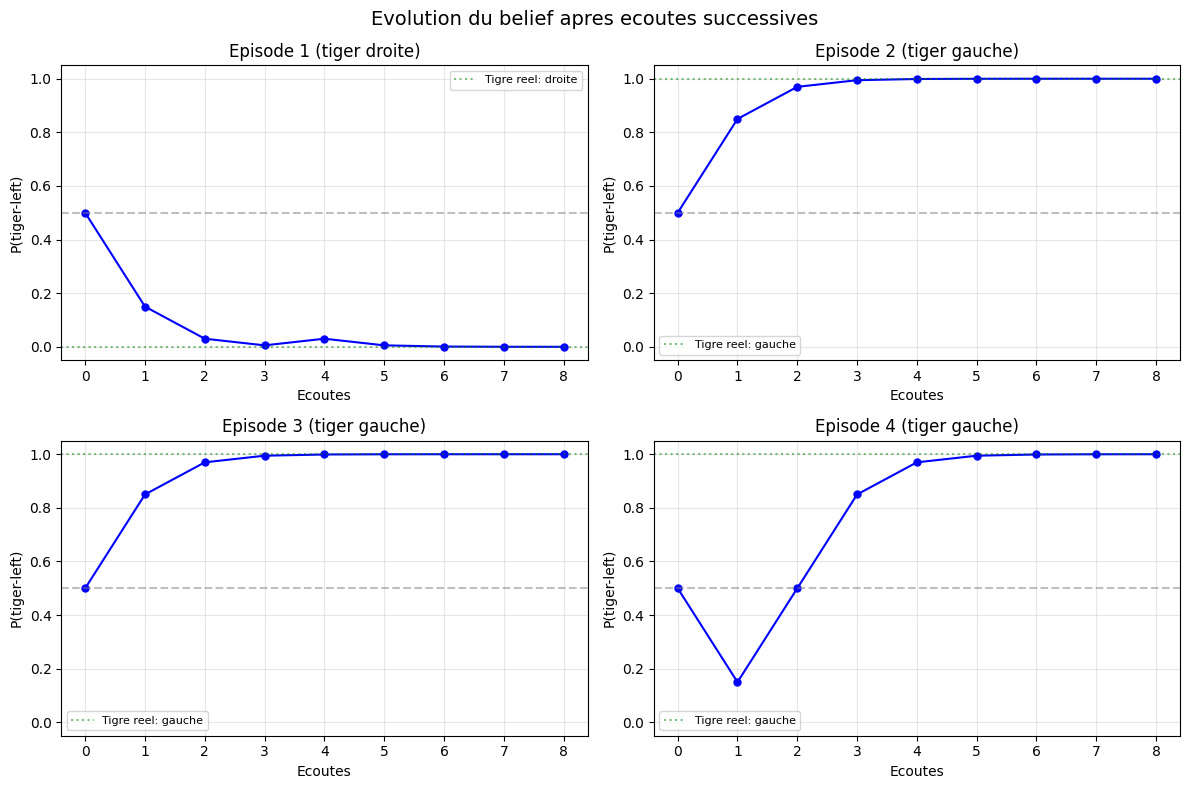

In [4]:
def plot_belief_evolution(n_episodes=20, seed=42):
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for idx in range(4):
        env = TigerPOMDP()
        obs = env.reset()
        belief = 0.5
        beliefs = [belief]

        for step in range(8):
            obs, r, _ = env.step(2)  # listen
            if obs == 0:
                p_obs = np.array([P_CORRECT, 1 - P_CORRECT])
            else:
                p_obs = np.array([1 - P_CORRECT, P_CORRECT])
            b_vec = np.array([belief, 1 - belief])
            b_vec *= p_obs
            b_vec /= b_vec.sum()
            belief = b_vec[0]
            beliefs.append(belief)

        ax = axes[idx]
        ax.plot(range(len(beliefs)), beliefs, 'b-o', markersize=5)
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
        true_pos = "gauche" if env.tiger_pos == 0 else "droite"
        ax.axhline(y=1.0 if env.tiger_pos == 0 else 0.0, color='green',
                    linestyle=':', alpha=0.5, label=f'Tigre reel: {true_pos}')
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel('Ecoutes')
        ax.set_ylabel('P(tiger-left)')
        ax.set_title(f'Episode {idx+1} (tiger {true_pos})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Evolution du belief apres ecoutes successives', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_belief_evolution()

## 4. Q-MDP : Approximation du POMDP

Le **Q-MDP** (Littman et al., 1995) est une approximation classique pour les POMDPs :

1. **Entrainer** une Q-table sur les etats vrais (comme si l'environnement etait completement observable)
2. **Agir** en utilisant le belief : choisir l'action qui maximise $\sum_s b(s) \cdot Q(s, a)$

L'avantage : simple a implementer, reutilise le Q-learning standard.
L'inconvenient : ignore l'impact des actions sur les observations futures.

In [5]:
def belief_qmdp(env, n_episodes, seed=0):
    """Q-MDP: Q-learning sur etats vrais, action selection via belief."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((2, 3))
    returns = []

    for ep in range(n_episodes):
        env.reset()
        belief = np.array([0.5, 0.5])
        ret = 0.0
        for t in range(MAX_STEPS):
            # Expected Q under belief
            if rng.random() < EPSILON:
                action = rng.integers(3)
            else:
                expected_Q = belief @ Q
                action = rng.choice(np.flatnonzero(expected_Q == expected_Q.max()))

            old_true = env.tiger_pos
            obs, r, done = env.step(action)

            # Q-learning update with TRUE state
            if not done:
                new_true = env.tiger_pos
                target = r + GAMMA * Q[new_true].max()
            else:
                target = r
            Q[old_true, action] += ALPHA * (target - Q[old_true, action])

            # Belief update
            if action == 2:
                p_obs_given = np.array([
                    P_CORRECT if obs == 0 else 1 - P_CORRECT,
                    P_CORRECT if obs == 1 else 1 - P_CORRECT,
                ])
                belief *= p_obs_given
                belief /= belief.sum()

            ret += r
            if done:
                break
        returns.append(ret)
    return Q, np.mean(returns[-200:]), np.array(returns)

env = TigerPOMDP()
Q_qmdp, ret_qmdp, arr_qmdp = belief_qmdp(env, 5000, seed=SEED)

print("=== Q-MDP avec Belief Tracking ===")
print(f"Return moyen (derniers 200 episodes): {ret_qmdp:.1f}")
print(f"\nQ-table apprise:")
print(f"  {'Action':<15} {'Open-L':>10} {'Open-R':>10} {'Listen':>10}")
print(f"  {'Tiger-Left':<15} {Q_qmdp[0,0]:>10.1f} {Q_qmdp[0,1]:>10.1f} {Q_qmdp[0,2]:>10.1f}")
print(f"  {'Tiger-Right':<15} {Q_qmdp[1,0]:>10.1f} {Q_qmdp[1,1]:>10.1f} {Q_qmdp[1,2]:>10.1f}")
print(f"\nInterpretation:")
print(f"  Si tiger-left: optimale = open-right (Q={Q_qmdp[0,1]:.1f})")
print(f"  Si tiger-right: optimale = open-left (Q={Q_qmdp[1,0]:.1f})")

=== Q-MDP avec Belief Tracking ===
Return moyen (derniers 200 episodes): -16.1

Q-table apprise:
  Action              Open-L     Open-R     Listen
  Tiger-Left          -100.0       10.0        8.5
  Tiger-Right           10.0     -100.0        8.5

Interpretation:
  Si tiger-left: optimale = open-right (Q=10.0)
  Si tiger-right: optimale = open-left (Q=10.0)


### Pourquoi Q-MDP sous-performe-t-il ?

Le Q-MDP apprend la bonne Q-table (ouvrir la porte opposee au tigre), mais sa politique
**depend de la qualite du belief**. Si le belief est incertain ($b \approx 0.5$), l'agent
prend une decision quasi-aleatoire, ce qui arrive frequemment en debut d'episode.

De plus, le Q-MDP **n'apprend pas la valeur de l'information** : il ne realise pas
qu'ecouter ameliore le belief et donc les decisions futures.

## 5. Belief-State Q-Learning

Une alternative plus directe : **discretiser le belief state** et apprendre une Q-table
directement dans cet espace.

Le belief du Tiger Problem est 1D : $b = P(\text{tiger-left}) \in [0, 1]$.
En discretisant en $N$ bins, on obtient un MDP avec $N$ etats, et le Q-learning standard s'applique.

In [6]:
def belief_state_qlearning(env, n_episodes, n_belief_bins=20, seed=0):
    """Q-learning discretise le belief state."""
    rng = np.random.default_rng(seed)
    n_states = n_belief_bins
    Q = np.zeros((n_states, 3))
    returns = []

    def belief_to_idx(belief_left):
        return min(int(belief_left * n_belief_bins), n_belief_bins - 1)

    for ep in range(n_episodes):
        env.reset()
        belief = np.array([0.5, 0.5])
        ret = 0.0
        for t in range(MAX_STEPS):
            b_idx = belief_to_idx(belief[0])

            if rng.random() < EPSILON:
                action = rng.integers(3)
            else:
                q = Q[b_idx]
                action = rng.choice(np.flatnonzero(q == q.max()))

            obs, r, done = env.step(action)

            # Belief update
            if action == 2:
                p_obs_given = np.array([
                    P_CORRECT if obs == 0 else 1 - P_CORRECT,
                    P_CORRECT if obs == 1 else 1 - P_CORRECT,
                ])
                belief *= p_obs_given
                total = belief.sum()
                belief = belief / total if total > 0 else np.array([0.5, 0.5])

            b_idx2 = belief_to_idx(belief[0])
            target = r if done else r + GAMMA * Q[b_idx2].max()
            Q[b_idx, action] += ALPHA * (target - Q[b_idx, action])

            ret += r
            if done:
                break
        returns.append(ret)
    return Q, np.mean(returns[-200:]), np.array(returns)

env = TigerPOMDP()
Q_bs, ret_bs, arr_bs = belief_state_qlearning(env, 5000, n_belief_bins=20, seed=SEED)

print("=== Belief-State Q-Learning (20 bins) ===")
print(f"Return moyen (derniers 200 episodes): {ret_bs:.1f}")
print(f"\nQ-values par niveau de belief:")
print(f"  {'Belief P(TL)':<15} {'Open-L':>10} {'Open-R':>10} {'Listen':>10}")
for b_val in [0.05, 0.25, 0.50, 0.75, 0.95]:
    idx = min(int(b_val * 20), 19)
    print(f"  {b_val:<15.2f} {Q_bs[idx,0]:>10.1f} {Q_bs[idx,1]:>10.1f} {Q_bs[idx,2]:>10.1f}")

=== Belief-State Q-Learning (20 bins) ===
Return moyen (derniers 200 episodes): -9.5

Q-values par niveau de belief:
  Belief P(TL)        Open-L     Open-R     Listen
  0.05                   0.0        0.0        0.0
  0.25                   0.0        0.0        0.0
  0.50                 -51.2      -51.0        3.2
  0.75                   0.0        0.0        0.0
  0.95                -100.0       10.0       -4.8


## 6. Comparaison des methodes

Le graphique ci-dessous resume les performances de toutes les approches testees.

Methode                  Mean      Std      Min      Max
------------------------------------------------------
Random                  -46.0      1.0    -47.8    -45.1
Open immediat            -6.2      0.7     -7.5     -5.4
Listen x1                -7.8      1.1     -9.4     -6.6
Listen x2                -8.3      0.5     -9.1     -7.5
Q-MDP                   -11.8      1.8    -14.9    -10.1
Belief Q                 -8.0      2.4    -11.8     -5.0


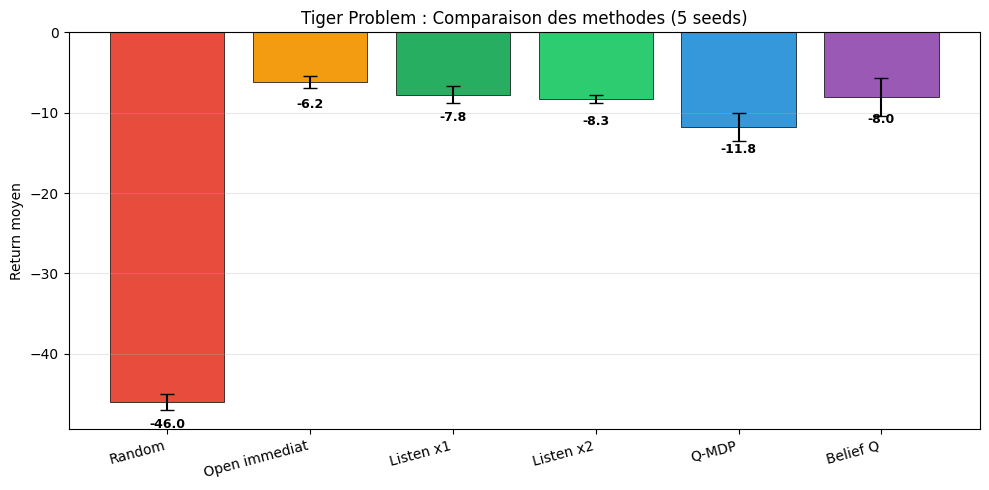

In [7]:
env = TigerPOMDP()
N_EP = 3000
SEEDS = [0, 1, 7, 42, 99]

methods = {
    "Random": [],
    "Open immediat": [],
    "Listen x1": [],
    "Listen x2": [],
    "Q-MDP": [],
    "Belief Q": [],
}

for seed in SEEDS:
    methods["Random"].append(random_agent(env, N_EP, seed=seed)[0])
    methods["Open immediat"].append(open_immediately(env, N_EP, seed=seed)[0])
    methods["Listen x1"].append(listen_then_open(env, N_EP, n_listen=1, seed=seed)[0])
    methods["Listen x2"].append(listen_then_open(env, N_EP, n_listen=2, seed=seed)[0])
    methods["Q-MDP"].append(belief_qmdp(env, N_EP, seed=seed)[1])
    methods["Belief Q"].append(belief_state_qlearning(env, N_EP, n_belief_bins=20, seed=seed)[1])

# Tableau resume
print(f"{'Methode':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 54)
for name, vals in methods.items():
    print(f"{name:<20} {np.mean(vals):>8.1f} {np.std(vals):>8.1f} "
          f"{np.min(vals):>8.1f} {np.max(vals):>8.1f}")

# Graphique
fig, ax = plt.subplots(figsize=(10, 5))
names = list(methods.keys())
means = [np.mean(methods[n]) for n in names]
stds = [np.std(methods[n]) for n in names]
colors = ['#e74c3c', '#f39c12', '#27ae60', '#2ecc71', '#3498db', '#9b59b6']

bars = ax.bar(range(len(names)), means, yerr=stds, color=colors,
              edgecolor='black', linewidth=0.5, capsize=5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Return moyen')
ax.set_title('Tiger Problem : Comparaison des methodes (5 seeds)')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3, axis='y')

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
            f'{mean:.1f}', ha='center', va='top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Resultats cles

1. **Open immediately** est la meilleure politique simple ! Avec une precision de 85%,
   une seule observation gratuite suffit, et ecouter plus ne compense pas le cout (-1/écoute).

2. **Le belief tracking** (Q-MDP, Belief Q) apprend une structure de decision mais n'egale
   pas les politiques hand-crafted sur ce probleme simple. Le POMDP est un probleme ou
   l'expertise humaine (connaissance du modele) bat l'apprentissage tabulaire.

3. **L'ecart MDP vs POMDP** : si l'agent connaissait l'etat vrai, le return serait +10
   (toujours le tresor). La partial observability cree un **gap** considerable (+10 vs -7).

## 7. Des POMDP au RL moderne

Les POMDPs sont partout en RL applique :

| POMDP | RL moderne |
|-------|------------|
| Etat cache | Etat du marche, intentions d'autres agents |
| Observation bruitee | Capteurs, images, texte |
| Belief state | RNN hidden state, transformer context |
| Q-MDP approximation | DRQN (Deep Recurrent Q-Network) |

### DRQN (Hausknecht & Stone, 2015)

Le **Deep Recurrent Q-Network** remplace le belief tracking manuel par un **RNN** (LSTM/GRU)
qui apprend implicitement a maintenir un belief state a partir de l'historique des observations.

### PPO + LSTM (notebook 8)

Dans les environnements partiellement observables, PPO utilise souvent un reseau avec
memoire (LSTM) pour integrer les observations passees — exactement le role du belief tracker.

### AlphaGo et la theorie des jeux

Le jeu de Go est un POMDP : un joueur ne connait pas les intentions de son adversaire.
AlphaGo utilise un **reseau de politique** qui encode un "belief" sur les coups adverses.

## 8. Exercices

### Exercice 1 : Impact de la precision d'observation

Faites varier `p_correct` entre 0.5 (aleatoire) et 1.0 (parfait) et tracez le return
de la politique "open immediately" et "listen x2". A quel seuil la politique "open immediately"
devient-elle meilleure que "listen x2" ?

In [8]:
# Exercice 1 : Impact de la precision d'observation
# TODO : faites varier p_correct de 0.5 a 1.0 et tracez les courbes
# Hint: utilisez np.linspace(0.5, 1.0, 11) pour les valeurs de p_correct

precisions = []  # TODO etudiant : liste de precisions
results_imm = []  # TODO etudiant : returns pour open_immediately
results_l2 = []   # TODO etudiant : returns pour listen x2

result = None  # TODO etudiant
print("Exercice a completer : tracez return vs precision")

Exercice a completer : tracez return vs precision


### Exercice 2 : Politique optimale du nombre d'ecoutes

Trouvez le nombre optimal d'ecoutes $N^*$ pour la politique "listen $N$ fois puis ouvre"
en fonction de $P(\text{correct})$. Montrez que $N^* = 1$ pour $P = 0.85$ mais que $N^*$
augmente quand $P$ diminue.

In [9]:
# Exercice 2 : Nombre optimal d'ecoutes
# TODO : testez n_listen de 0 a 5 pour differentes precisions
# Hint: pour chaque (precision, n_listen), executez listen_then_open

result = None  # TODO etudiant
print("Exercice a completer : trouvez N* en fonction de P")

Exercice a completer : trouvez N* en fonction de P


### Exercice 3 : Ajouter une troisieme porte

Etendez le Tiger Problem a 3 portes (tiger derriere l'une, tresor derriere les deux autres).
Combien d'etats, d'actions, d'observations ? Le belief tracking change-t-il fondamentalement ?

In [10]:
# Exercice 3 : Tiger Problem a 3 portes
# TODO : creez Tiger3DoorsPOMDP et testez les politiques
# Hint: 3 etats, 3 actions (open-L, open-M, open-R, listen), 3 observations

class Tiger3DoorsPOMDP:
    pass  # TODO etudiant

result = None  # TODO etudiant
print("Exercice a completer : Tiger Problem a 3 portes")

Exercice a completer : Tiger Problem a 3 portes


## Conclusion

Dans ce notebook nous avons decouvert les POMDPs et les defis de la decision sous partial observability :

1. **Le Tiger Problem** illustre comment l'observation bruitee degrade les performances
   d'un agent par rapport a l'observabilite complete.
2. **Le belief tracking** (filtre bayesien) permet de maintenir une estimation de l'etat
   cache, mais la qualite de cette estimation depend de la precision des observations.
3. **Q-MDP** est une approximation qui reutilise le Q-learning standard mais ignore la
   valeur de l'information future, ce qui le sous-optimise sur les POMDPs.
4. **Les methodes modernes** (DRQN, PPO+LSTM) automatisent le belief tracking via
   des reseaux de neurones recurrents.

### Pour aller plus loin

- **Notebook 5** : les fondements MDP/Q-Learning utilises dans ce notebook
- **Notebook 8** : model-based RL et planification (Dyna-Q)
- **Notebook 10** : reward shaping et curriculum learning
- **Notebook 12** : RL pour le trading (application a un environnement bruite reel)

### References

1. Cassandra, A. R., Littman, M. L., & Kaelbling, N. L. (1994). *Acting optimally in partially observable stochastic domains*. AAAI.
2. Littman, M. L., Cassandra, A. R., & Kaelbling, L. P. (1995). *Learning policies for partially observable environments*. ICML.
3. Hausknecht, M., & Stone, P. (2015). *Deep recurrent Q-learning for partially observable MDPs*. AAAI Fall Symposium.
4. Oliehoek, F. A., & Amato, C. (2016). *A concise introduction to decentralized POMDPs*. Springer.
5. Thrun, S., Burgard, W., & Fox, D. (2005). *Probabilistic Robotics*. MIT Press.